In [1]:
import neuralprophet, torch
print("neuralprophet:", neuralprophet.__version__)
print("torch:        ", torch.__version__)
#print("lightning:    ", pytorch_lightning.__version__)

neuralprophet: 0.4.2
torch:         1.11.0


In [2]:
import os 
import logging
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from simulate_ordinal_ts import simulate_ordinal_timeseries, build_trend
from scipy.stats import spearmanr
from OrdinalNeuralProphet import OrdinalNeuralProphet
from run_experiments import (BASE_SIM, BASE_MODEL, make_config, run_experiment,
                             pretty_summary, experiment_noise_sweep,
                             experiment_multiseed)

# NeuralProphet logs an INFO line per fit, which is unreadable across a sweep.
warnings.filterwarnings("ignore")
logging.getLogger("NP").setLevel(logging.ERROR)

In [3]:
os.makedirs('figures', exist_ok=True)
os.makedirs('results', exist_ok=True)

In [4]:
# Beijing AQI data. Categories follow HJ 633-2012 PM2.5 cut-points at 35, 75, 150.
df = pd.read_csv('data/BeijingAQI_data.csv', parse_dates=['datetime'])

In [5]:
# Smoke test: single train/test split on Beijing AQI.
# NOT the paper's configuration -- the reported Beijing results come from
# run_beijing_horizon.py (epochs=40, ar_reg=0.5, expanding-window evaluation).

df = df.set_index('datetime')

model = OrdinalNeuralProphet(
    df,
    'aqi_category',
    seed=42,
    n_lags=24,
    n_forecasts=12,
    test_periods=72,
    val_periods=500,
    num_categories=4,
    freq='h',
    covariates=['TEMP', 'DEWP', 'PRES', 'Iws'],         # lagged regressors
    future_covariates=['TEMP', 'DEWP', 'PRES', 'Iws'],  # future regressors
    forecast_only=False,
    round_intermediate=False,   # feed back continuous predictions, not categories
    val_mode='refit',
    epochs=50
    #learning_rate=0.03,
)

Data split:
  Training:   2976 samples (indices 0 to 2975)
  Validation: 500 samples (indices 2976 to 3475)
  Test:       72 samples (indices 3476 to 3547)
  Val mode:   refit (model fit on train+validation; thresholds tuned on its own validation predictions)


  0%|          | 0/138 [00:00<?, ?it/s]

  0%|          | 0/138 [00:00<?, ?it/s]

TEST SET ASSESSMENT (72 samples):
Exact Accuracy: 0.444
Within-1 Accuracy: 1.000
MAE (ordinal): 0.556


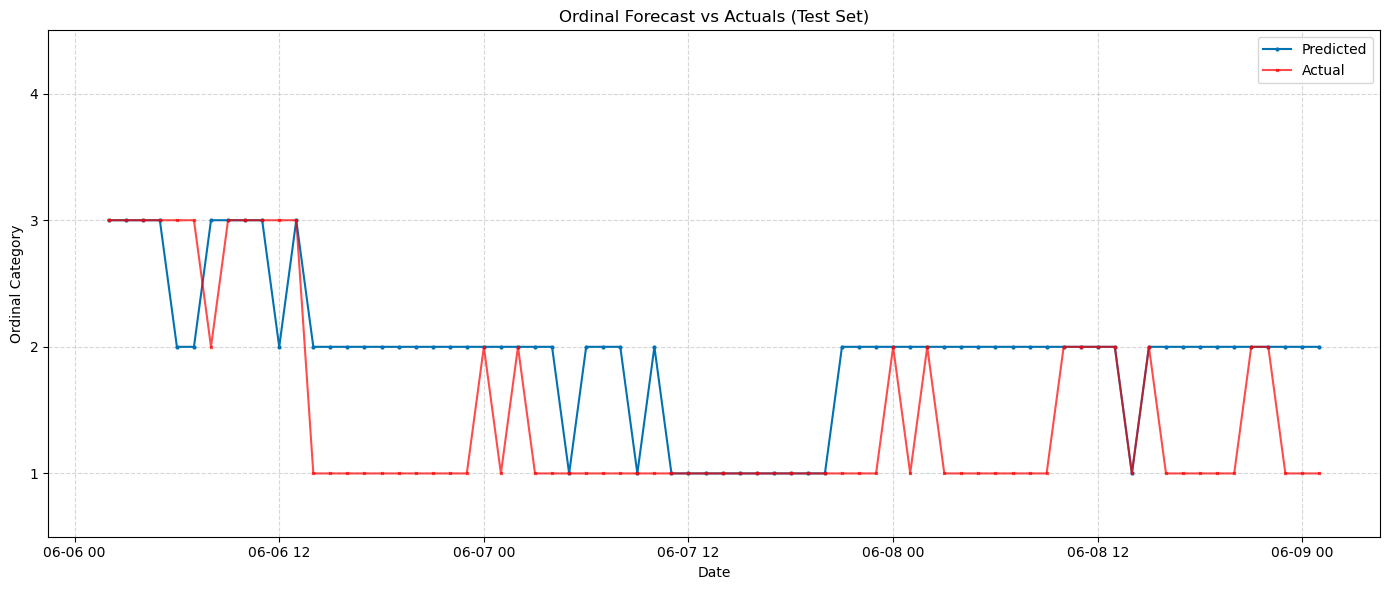

In [6]:
model.assessment()
model.plot_forecast()

Optimizing thresholds...
  Val mode: refit
  Gap method: softplus
  Validation set: 500 samples
  Test set: 72 samples
  Kappa weights: quadratic
  Optimization starts: 200

THRESHOLD OPTIMIZATION RESULTS

Gap Method: softplus
Optimal Thresholds: ['1.9601', '2.3662', '2.8886']
Validation Kappa: 0.7136
Threshold Gaps: ['0.4062', '0.5223']

TEST SET PERFORMANCE (72 samples):
Metric                    Baseline     Optimized    Change      
------------------------------------------------------------
Kappa (quadratic)         0.4857       0.6985       +0.2127
Exact Accuracy            0.4444       0.6806       +0.2361
Within-1 Accuracy         1.0000       0.9861       -0.0139
MAE                       0.5556       0.3333       -0.2222


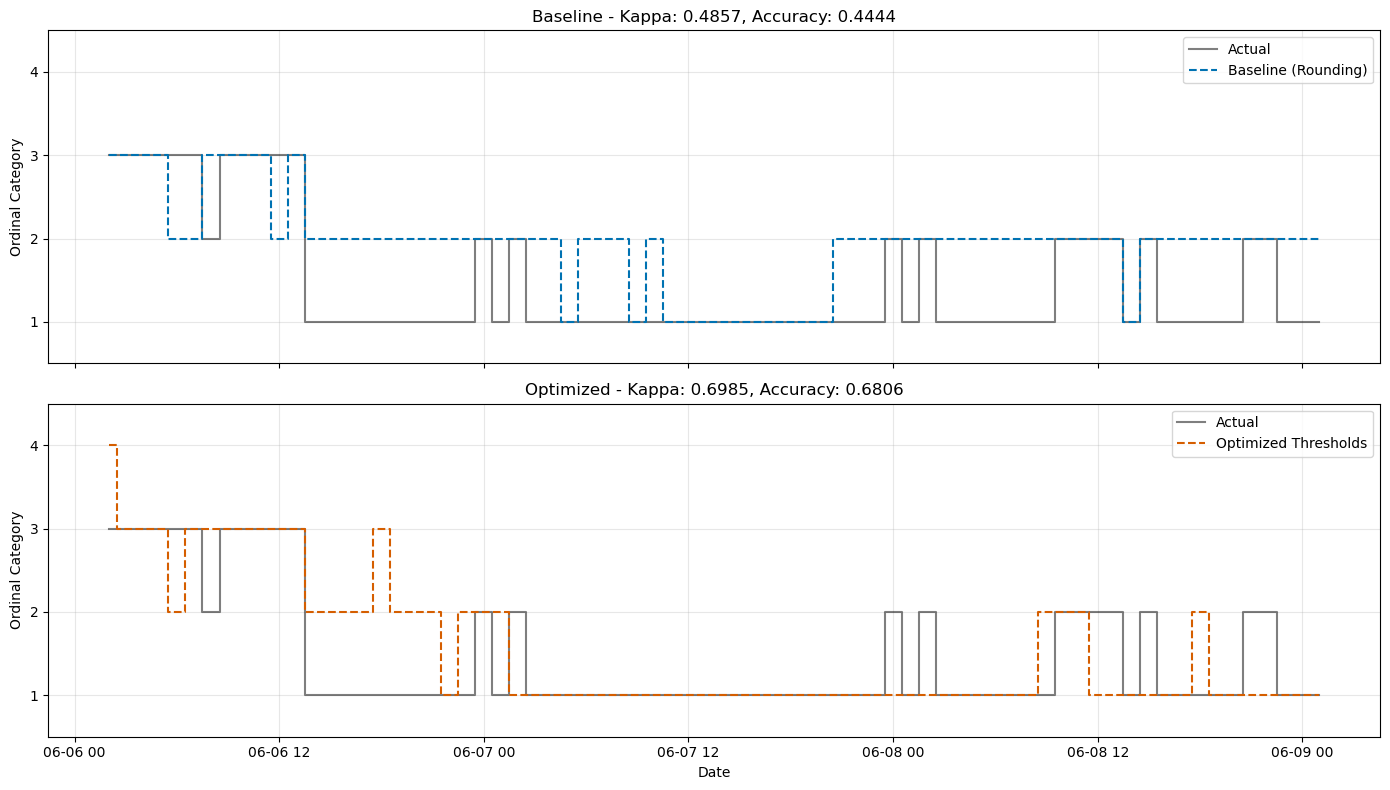

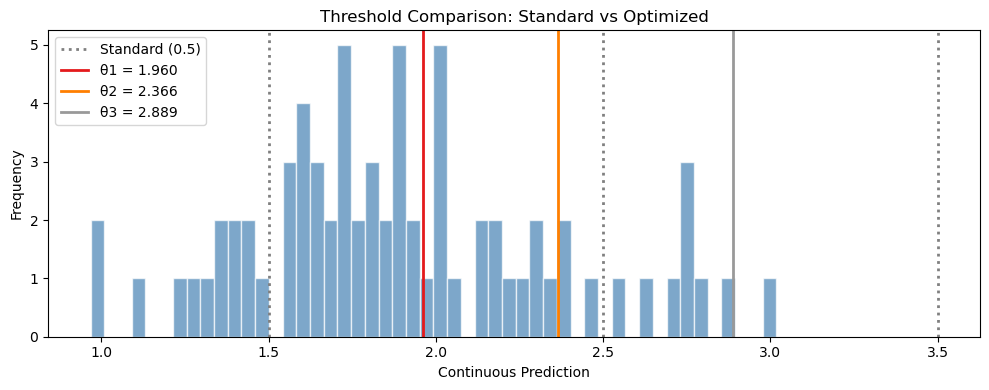

In [7]:
results = model.optimize_thresholds(gap_method='softplus',
    n_starts=200,
    kappa_weights="quadratic"
)
model.plot_comparison()

GROUND TRUTH
  thresholds (latent z): ['-0.800', '0.000', '1.000']
  betas:                 [0.3, 0.2, -0.4, 0.15]
  AR coefs:              [0.5]
  trend slope:           -9e-05
  daily / weekly amp:    0.6 / 0.3
  noise std:             0.25
  category proportions:  ['0.386', '0.199', '0.210', '0.205']
Data split:
  Training:   2928 samples (indices 0 to 2927)
  Validation: 500 samples (indices 2928 to 3427)
  Test:       72 samples (indices 3428 to 3499)
  Val mode:   refit (model fit on train+validation; thresholds tuned on its own validation predictions)


  0%|          | 0/138 [00:00<?, ?it/s]

  0%|          | 0/138 [00:00<?, ?it/s]

TEST SET ASSESSMENT (72 samples):
Exact Accuracy: 0.722
Within-1 Accuracy: 1.000
MAE (ordinal): 0.278


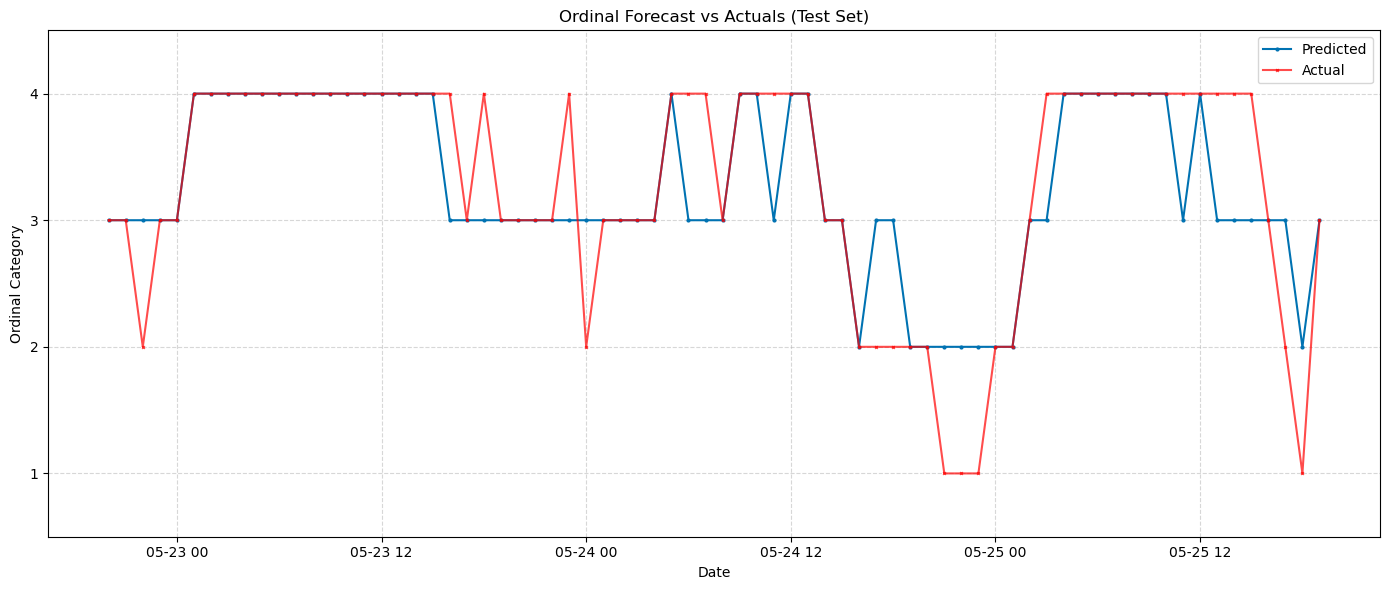

Optimizing thresholds...
  Val mode: refit
  Gap method: softplus
  Validation set: 500 samples
  Test set: 72 samples
  Kappa weights: quadratic
  Optimization starts: 200

THRESHOLD OPTIMIZATION RESULTS

Gap Method: softplus
Optimal Thresholds: ['1.9630', '2.5381', '3.2144']
Validation Kappa: 0.8836
Threshold Gaps: ['0.5750', '0.6764']

TEST SET PERFORMANCE (72 samples):
Metric                    Baseline     Optimized    Change      
------------------------------------------------------------
Kappa (quadratic)         0.7800       0.8657       +0.0857
Exact Accuracy            0.7222       0.8056       +0.0833
Within-1 Accuracy         1.0000       1.0000       +0.0000
MAE                       0.2778       0.1944       -0.0833


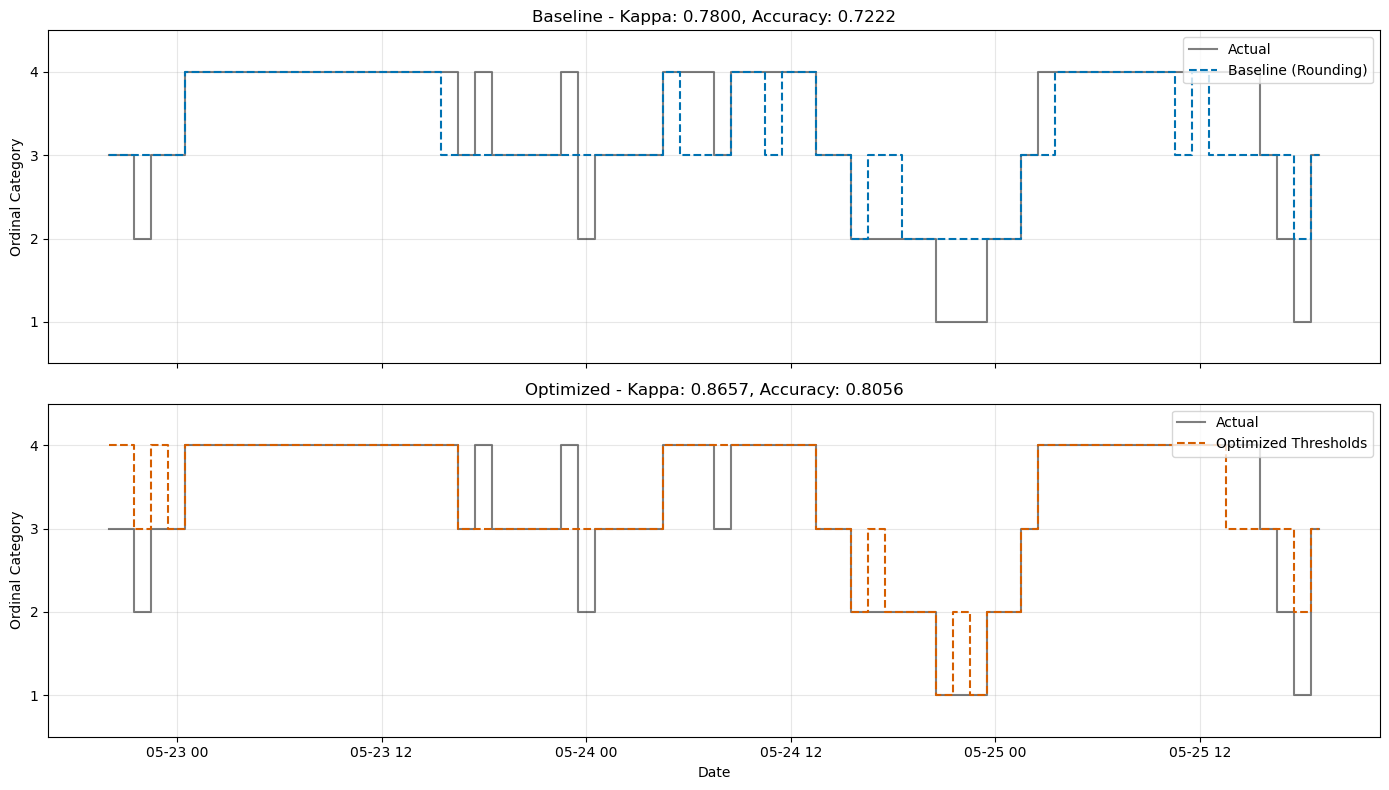

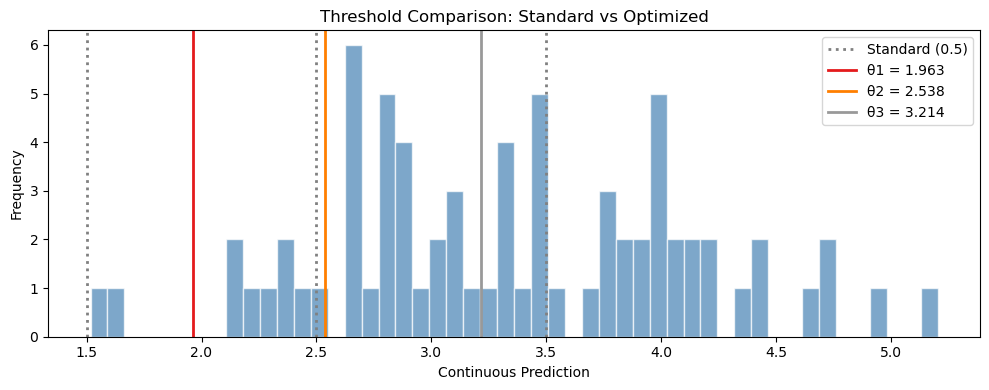

In [8]:
# =========================================================================
# Worked example: one simulation run at the reference configuration.
# The paper's simulation results pool many seeds via run_experiments.py;
# this cell is a single run for inspection.
# =========================================================================

SEED = 42   # injected into both the DGP and the model, as in run_once()

# --- 1. simulate (parameters are Table 2 of the paper) --------------------
df, truth = simulate_ordinal_timeseries(
    n=3500,
    start_date='2024-01-01 00:00:00',
    freq='h',
    num_categories=4,
    thresholds=[-0.8, 0.0, 1.0],   # fixed, so class shares emerge from the process
    trend_slope=-9e-5,             # total drift over n=3500 is about -0.32 in z
    daily_amplitude=0.6,
    weekly_amplitude=0.3,
    betas=(0.30,    # X1, temp-like
           0.20,    # X2, dewp-like, correlated with X1 at rho=0.7
          -0.40,    # X3, pres-like
           0.15),   # X4, wind-like, spiky
    ar_coefs=(0.5,),
    noise_std=0.25,
    seed=SEED,
)
df = df.set_index('datetime')

print("GROUND TRUTH")
print(f"  thresholds (latent z): {[f'{t:.3f}' for t in truth['thresholds']]}")
print(f"  betas:                 {truth['betas']}")
print(f"  AR coefs:              {truth['ar_coefs']}")
print(f"  trend slope:           {truth['trend_slope']}")
print(f"  daily / weekly amp:    {truth['daily_amplitude']} / {truth['weekly_amplitude']}")
print(f"  noise std:             {truth['noise_std']}")
print(f"  category proportions:  {[f'{p:.3f}' for p in truth['category_proportions']]}")

# --- 2. fit ---------------------------------------------------------------
model = OrdinalNeuralProphet(
    df,
    target='aqi_category',
    seed=SEED,
    n_lags=24,          # L_a
    n_forecasts=12,     # B, the output block width
    test_periods=72,    # N, the blind forecast horizon
    val_periods=500,
    num_categories=4,
    freq='h',
    covariates=['X1', 'X2', 'X3', 'X4'],         # lagged regressors
    future_covariates=['X1', 'X2', 'X3', 'X4'],  # future regressors
    forecast_only=False,
    round_intermediate=False,
    val_mode='refit',
    epochs=50,
    ar_reg=0.5,
)

# --- 3. baseline: naive rounding -----------------------------------------
model.assessment()
model.plot_forecast()

# --- 4. threshold optimization -------------------------------------------
results = model.optimize_thresholds(
    gap_method='softplus',
    n_starts=200,
    kappa_weights='quadratic',
)
model.plot_comparison()

Data split:
  Training:   2928 samples (indices 0 to 2927)
  Validation: 500 samples (indices 2928 to 3427)
  Test:       72 samples (indices 3428 to 3499)
  Val mode:   refit (model fit on train+validation; thresholds tuned on its own validation predictions)


  0%|          | 0/138 [00:00<?, ?it/s]

  0%|          | 0/138 [00:00<?, ?it/s]

TEST SET ASSESSMENT (72 samples):
Exact Accuracy: 0.722
Within-1 Accuracy: 1.000
MAE (ordinal): 0.278
Optimizing thresholds...
  Val mode: refit
  Gap method: softplus
  Validation set: 500 samples
  Test set: 72 samples
  Kappa weights: quadratic
  Optimization starts: 200

THRESHOLD OPTIMIZATION RESULTS

Gap Method: softplus
Optimal Thresholds: ['1.9630', '2.5381', '3.2144']
Validation Kappa: 0.8836
Threshold Gaps: ['0.5750', '0.6764']

TEST SET PERFORMANCE (72 samples):
Metric                    Baseline     Optimized    Change      
------------------------------------------------------------
Kappa (quadratic)         0.7800       0.8657       +0.0857
Exact Accuracy            0.7222       0.8056       +0.0833
Within-1 Accuracy         1.0000       1.0000       +0.0000
MAE                       0.2778       0.1944       -0.0833


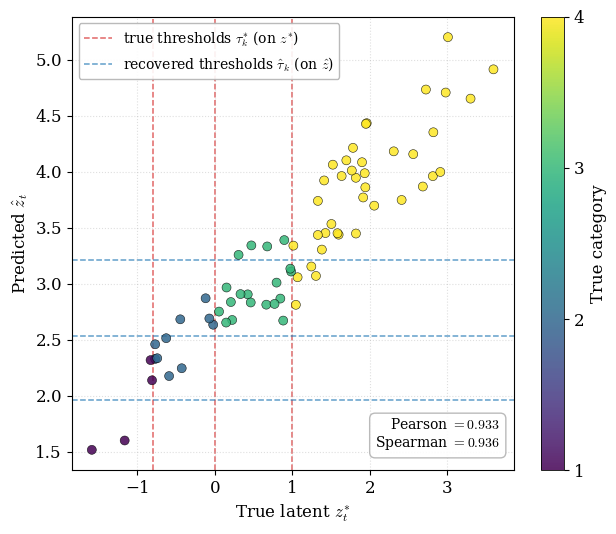

In [9]:
# =========================================================================
# Figure 2: continuous forecast against the true latent variable.
#
# Refits the reference configuration (BASE_SIM / BASE_MODEL in
# run_experiments.py) at seed 42, the representative seed used in the paper,
# and plots the test-window forecast z-hat against the true latent z*,
# coloured by true category. Red verticals are the true thresholds on z*,
# blue horizontals the recovered thresholds on z-hat.
#
# Writes: figures/sim_latent_recovery.pdf (and .png preview)
# =========================================================================

os.makedirs('figures', exist_ok=True)

# --- refit the reference config at seed 42 (the representative seed) ---
df, truth = simulate_ordinal_timeseries(**{**BASE_SIM, 'seed': 42})
df = df.set_index('datetime')
model = OrdinalNeuralProphet(df, target='aqi_category', **{**BASE_MODEL, 'seed': 42})
model.assessment()
results = model.optimize_thresholds(gap_method='softplus', n_starts=200,
                                    kappa_weights='quadratic')

# --- pull the test-window arrays ---
ts, te = model.val_end_idx, model.test_end_idx
yhat_test = model.forecast_df['yhat_continuous'].iloc[ts:te].values
z_test    = df['y_latent'].iloc[ts:te].values
y_test    = df['aqi_category'].iloc[ts:te].values
mask = ~np.isnan(yhat_test)
yhat_test, z_test, y_test = yhat_test[mask], z_test[mask], y_test[mask]

rho_p = np.corrcoef(yhat_test, z_test)[0, 1]
rho_s = spearmanr(yhat_test, z_test).correlation

# --- publication styling ---
plt.rcParams.update({
    'font.size': 12, 'font.family': 'serif',
    'axes.linewidth': 0.8, 'mathtext.fontset': 'cm',
})

fig, ax = plt.subplots(figsize=(6.5, 5.5))

sc = ax.scatter(z_test, yhat_test, c=y_test, cmap='viridis',
                s=42, alpha=0.85, edgecolor='black', linewidth=0.4, zorder=3)
cbar = plt.colorbar(sc, label='True category', ticks=range(1, 5))
cbar.outline.set_linewidth(0.6)

# red verticals = TRUE thresholds (on z*); label only the first
for i, tau in enumerate(truth['thresholds']):
    ax.axvline(tau, color='#d62728', ls='--', lw=1.1, alpha=0.7, zorder=1,
               label=r'true thresholds $\tau^{*}_{k}$ (on $z^{*}$)' if i == 0 else None)

# blue horizontals = RECOVERED thresholds (on yhat); label only the first
for i, tau in enumerate(results['optimal_thresholds']):
    ax.axhline(tau, color='#1f77b4', ls='--', lw=1.1, alpha=0.7, zorder=1,
               label=r'recovered thresholds $\hat{\tau}_{k}$ (on $\hat{z}$)' if i == 0 else None)

ax.set_xlabel(r'True latent $z^{*}_{t}$')
ax.set_ylabel(r'Predicted $\hat{z}_{t}$')
ax.legend(loc='upper left', frameon=True, framealpha=0.9, fontsize=10, edgecolor='0.7')
ax.text(0.97, 0.04,
        f'Pearson $= {rho_p:.3f}$\nSpearman $= {rho_s:.3f}$',
        transform=ax.transAxes, ha='right', va='bottom', fontsize=10,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                  edgecolor='0.7', alpha=0.9))
ax.grid(True, ls=':', alpha=0.4, zorder=0)

plt.tight_layout()
plt.savefig('figures/sim_latent_recovery.pdf', bbox_inches='tight')           # vector -> LaTeX
plt.savefig('figures/sim_latent_recovery.png', dpi=300, bbox_inches='tight')  # preview
plt.show()

In [10]:
# =========================================================================
# Table 4: threshold optimization versus naive rounding at the reference
# configuration, and the latent-recovery correlations quoted in Section 4.1.4.
#
# Runs the reference config at 40 seeds (22-61). Each run generates a fresh
# 3500-hour series, fits on the training and validation blocks combined,
# tunes thresholds on the validation-block predictions, and evaluates on the
# untouched 72-hour test block. pretty_summary reports mean +/- SD across
# seeds.
#
# The test block is only 72 hours, so single-seed results vary widely
# (optimized kappa ranged from 0.648 to 0.931). Forty seeds is what makes the
# mean meaningful.
#
# Writes: results/multiseed_reference_40.csv
# =========================================================================

configs, seeds = experiment_multiseed(seeds=range(22, 62))
results = run_experiment(configs, seeds, save_path='results/multiseed_reference_40.csv')

pretty_summary(results, metrics=(
    'quadratic_optimized_kappa', 'quadratic_baseline_kappa', 'quadratic_kappa_improvement',
    'linear_optimized_kappa',    'linear_baseline_kappa',    'linear_kappa_improvement',
    'optimized_accuracy', 'baseline_accuracy', 'optimized_mae', 'baseline_mae',
    'spearman_recovery',
))

  0%|          | 0/138 [00:00<?, ?it/s]

  0%|          | 0/138 [00:00<?, ?it/s]

[  1/40] reference              seed=22 opt_kappa=0.832  (   19s)  


  0%|          | 0/138 [00:00<?, ?it/s]

  0%|          | 0/138 [00:00<?, ?it/s]

...

  0%|          | 0/138 [00:00<?, ?it/s]

[ 39/40] reference              seed=60 opt_kappa=0.891  (  720s)  


  0%|          | 0/138 [00:00<?, ?it/s]

  0%|          | 0/138 [00:00<?, ?it/s]

[ 40/40] reference              seed=61 opt_kappa=0.883  (  739s)  
config                 quadratic_optimized_kappa quadratic_baseline_kappa quadratic_kappa_improvement linear_optimized_kappa  linear_baseline_kappa linear_kappa_improvement     optimized_accuracy      baseline_accuracy          optimized_mae           baseline_mae      spearman_recovery    n
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
reference                     0.851 +/- 0.061        0.798 +/- 0.053        0.054 +/- 0.051        0.750 +/- 0.080        0.679 +/- 0.072        0.071 +/- 0.078        0.764 +/- 0.052        0.702 +/- 0.066        0.243 +/- 0.055        0.301 +/- 0.067        0.931 +/- 0.020   40


In [11]:
# =========================================================================
# Setup for Figure 3: extract the fitted decomposition at the reference
# configuration, seed 42.
#
# Constructing OrdinalNeuralProphet fits the model, so fitted_model is
# available without a separate call. make_future_dataframe with
# n_historic_predictions=True and periods=0 asks NeuralProphet for the
# in-sample decomposition over the historic window, which is what gets
# compared against the true generating components in the next cell.
# These are historic fitted values, not a forecast.
# =========================================================================

SEED = 42

df, truth = simulate_ordinal_timeseries(**{**BASE_SIM, 'seed': SEED})
df = df.set_index('datetime')

model = OrdinalNeuralProphet(df, target='aqi_category', **{**BASE_MODEL, 'seed': SEED})

m = model.fitted_model
future_df = m.make_future_dataframe(
    df=model.prophet_data,
    n_historic_predictions=True,
    periods=0,
)
forecast = m.predict(future_df)

print(f"forecast shape: {forecast.shape}")
print("decomposition columns present:",
      [c for c in ['trend', 'season_daily', 'season_weekly',
                   'future_regressors_additive'] if c in forecast.columns])

Data split:
  Training:   2928 samples (indices 0 to 2927)
  Validation: 500 samples (indices 2928 to 3427)
  Test:       72 samples (indices 3428 to 3499)
  Val mode:   refit (model fit on train+validation; thresholds tuned on its own validation predictions)


  0%|          | 0/138 [00:00<?, ?it/s]

  0%|          | 0/138 [00:00<?, ?it/s]

forecast shape: (3500, 94)
decomposition columns present: ['trend', 'season_daily', 'season_weekly', 'future_regressors_additive']


Comparing 3476 aligned timesteps.

Component                  corr(fit, true)
------------------------------------------
Trend                                0.200
Daily seasonality                    0.926
Weekly seasonality                   0.996
Total covariate eff                  0.971

True trend slope:      -9.00e-05
Fitted trend slope:    -1.18e-05
Slope agreement ratio: 0.131

Per-covariate      corr      true β    recovered β   sign match
------------------------------------------------------------
X1             1.000       0.300         0.5540            ✓
X2             1.000       0.200         0.1336            ✓
X3             1.000      -0.400        -0.2537            ✓
X4             1.000       0.150         0.0910            ✓


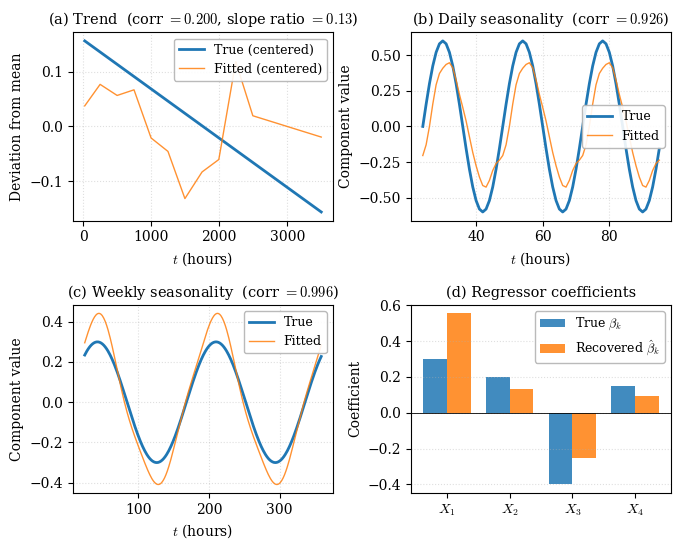

In [12]:
# =========================================================================
# Figure 3 and Table 3: fitted components against the true generating
# components, reference configuration at seed 42.
#
# Requires the previous cell (uses `forecast`, `df` and `truth`).
#
# Aligns the in-sample decomposition with the simulator's ground truth on
# `ds`, reconstructs the true trend, daily and weekly seasonality and
# covariate contributions from `truth`, and compares them component by
# component. Prints the correlations quoted in Section 4.1.4 and the
# coefficient comparison reported as Table 3.
#
# Single seed. Magnitudes are on the integer-label scale rather than the
# latent scale, so they are compressed relative to the truth (Section 4.1.2).
#
# Writes: figures/component_recovery.pdf (and .png preview)
# =========================================================================

# Align fitted decomposition with simulator ground truth by 'ds'
df_reset = df.reset_index().rename(columns={'datetime': 'ds'})
aligned = forecast.merge(df_reset, on='ds', how='inner')

need = ['trend', 'season_daily', 'season_weekly', 'future_regressors_additive']
aligned = aligned.dropna(subset=need).reset_index(drop=True)
n = len(aligned)
print(f"Comparing {n} aligned timesteps.\n")

# ---- True components ----
start_date = pd.to_datetime(truth.get('start_date', '2024-01-01 00:00:00'))
t = ((aligned['ds'] - start_date) / pd.Timedelta('1h')).astype(int).values

true_trend  = truth['trend_slope']      * t
true_daily  = truth['daily_amplitude']  * np.sin(2*np.pi*t/24  + truth['daily_phase'])
true_weekly = truth['weekly_amplitude'] * np.sin(2*np.pi*t/168 + truth['weekly_phase'])

X_mu  = np.array(truth['covariate_means_pre_std'])
X_sig = np.array(truth['covariate_stds_pre_std'])
X = aligned[['X1','X2','X3','X4']].astype(float).values
X_std = (X - X_mu) / X_sig
betas_true = np.array(truth['betas'])
true_cov_each  = X_std * betas_true
true_cov_total = X_std @ betas_true

# ---- Fitted components (force float64; NP 0.4.2 can return object dtype) ----
fit_trend     = aligned['trend'].astype(float).values
fit_daily     = aligned['season_daily'].astype(float).values
fit_weekly    = aligned['season_weekly'].astype(float).values
fit_cov_total = aligned['future_regressors_additive'].astype(float).values
fit_cov_each  = np.column_stack([
    aligned[f'future_regressor_X{i}__fut'].astype(float).values for i in (1,2,3,4)
])

# least-squares slope of each fitted contribution on its standardized covariate
beta_hat = np.array([
    np.dot(X_std[:,i], fit_cov_each[:,i]) / np.dot(X_std[:,i], X_std[:,i])
    for i in range(4)
])

true_slope = truth['trend_slope']
fit_slope  = np.polyfit(t, fit_trend, 1)[0]

def corr(a, b):
    return float(np.corrcoef(a, b)[0,1])

# ---- Printout ----
print(f"{'Component':<22}{'corr(fit, true)':>20}")
print("-" * 42)
print(f"{'Trend':<22}{corr(fit_trend,  true_trend):>20.3f}")
print(f"{'Daily seasonality':<22}{corr(fit_daily,  true_daily):>20.3f}")
print(f"{'Weekly seasonality':<22}{corr(fit_weekly, true_weekly):>20.3f}")
print(f"{'Total covariate eff':<22}{corr(fit_cov_total, true_cov_total):>20.3f}")
print()
print(f"True trend slope:      {true_slope:.2e}")
print(f"Fitted trend slope:    {fit_slope:.2e}")
print(f"Slope agreement ratio: {fit_slope / true_slope:.3f}")
print()
print(f"{'Per-covariate':<10}{'corr':>10}{'true β':>12}{'recovered β':>15}{'sign match':>13}")
print("-" * 60)
for i, name in enumerate(['X1','X2','X3','X4']):
    c = corr(fit_cov_each[:,i], true_cov_each[:,i])
    sm = '✓' if np.sign(beta_hat[i]) == np.sign(betas_true[i]) else '✗'
    print(f"{name:<10}{c:>10.3f}{betas_true[i]:>12.3f}{beta_hat[i]:>15.4f}{sm:>13}")

# ===============================================================
# Figure: 2x2 grid
# ===============================================================
plt.rcParams.update({
    'font.size': 10, 'font.family': 'serif',
    'axes.linewidth': 0.8, 'mathtext.fontset': 'cm',
    'axes.titlesize': 10.5, 'legend.fontsize': 9,
})
C_TRUE, C_FIT = '#1f77b4', '#ff7f0e'

fig, axes = plt.subplots(2, 2, figsize=(7.0, 5.6))

# (a) Trend, centered
ax = axes[0,0]
ax.plot(t, true_trend - true_trend.mean(), color=C_TRUE, lw=2, label='True (centered)')
ax.plot(t, fit_trend - fit_trend.mean(), color=C_FIT, lw=1, alpha=0.85, label='Fitted (centered)')
ax.set_title(f'(a) Trend  (corr $= {corr(fit_trend,true_trend):.3f}$, slope ratio $= {fit_slope/true_slope:.2f}$)')
ax.set_xlabel('$t$ (hours)'); ax.set_ylabel('Deviation from mean')
ax.legend(frameon=True, framealpha=0.9, edgecolor='0.7'); ax.grid(ls=':', alpha=0.4)

# (b) Daily seasonality, 3 days
ax = axes[0,1]; s = slice(0, min(72, n))
ax.plot(t[s], true_daily[s], color=C_TRUE, lw=2, label='True')
ax.plot(t[s], fit_daily[s], color=C_FIT, lw=1, alpha=0.85, label='Fitted')
ax.set_title(f'(b) Daily seasonality  (corr $= {corr(fit_daily,true_daily):.3f}$)')
ax.set_xlabel('$t$ (hours)'); ax.set_ylabel('Component value')
ax.legend(frameon=True, framealpha=0.9, edgecolor='0.7'); ax.grid(ls=':', alpha=0.4)

# (c) Weekly seasonality, 2 weeks
ax = axes[1,0]; s = slice(0, min(336, n))
ax.plot(t[s], true_weekly[s], color=C_TRUE, lw=2, label='True')
ax.plot(t[s], fit_weekly[s], color=C_FIT, lw=1, alpha=0.85, label='Fitted')
ax.set_title(f'(c) Weekly seasonality  (corr $= {corr(fit_weekly,true_weekly):.3f}$)')
ax.set_xlabel('$t$ (hours)'); ax.set_ylabel('Component value')
ax.legend(frameon=True, framealpha=0.9, edgecolor='0.7'); ax.grid(ls=':', alpha=0.4)

# (d) Regressor coefficients
ax = axes[1,1]
xp = np.arange(4); w = 0.38
ax.bar(xp - w/2, betas_true, w, color=C_TRUE, alpha=0.85, label=r'True $\beta_k$')
ax.bar(xp + w/2, beta_hat,   w, color=C_FIT,  alpha=0.85, label=r'Recovered $\hat{\beta}_k$')
ax.axhline(0, color='black', lw=0.6)
ax.set_xticks(xp); ax.set_xticklabels([f'$X_{i}$' for i in (1,2,3,4)])
ax.set_title('(d) Regressor coefficients')
ax.set_ylabel('Coefficient')
ax.legend(frameon=True, framealpha=0.9, edgecolor='0.7'); ax.grid(ls=':', alpha=0.4, axis='y')

plt.tight_layout()
plt.savefig('figures/component_recovery.pdf', bbox_inches='tight')           # vector -> LaTeX
plt.savefig('figures/component_recovery.png', dpi=300, bbox_inches='tight')  # preview
plt.show()

Data split:
  Training:   2928 samples (indices 0 to 2927)
  Validation: 500 samples (indices 2928 to 3427)
  Test:       72 samples (indices 3428 to 3499)
  Val mode:   refit (model fit on train+validation; thresholds tuned on its own validation predictions)


  0%|          | 0/138 [00:00<?, ?it/s]

  0%|          | 0/138 [00:00<?, ?it/s]

1 change: corr = 0.875
Data split:
  Training:   2928 samples (indices 0 to 2927)
  Validation: 500 samples (indices 2928 to 3427)
  Test:       72 samples (indices 3428 to 3499)
  Val mode:   refit (model fit on train+validation; thresholds tuned on its own validation predictions)


  0%|          | 0/138 [00:00<?, ?it/s]

  0%|          | 0/138 [00:00<?, ?it/s]

2 changes: corr = 0.752
Data split:
  Training:   2928 samples (indices 0 to 2927)
  Validation: 500 samples (indices 2928 to 3427)
  Test:       72 samples (indices 3428 to 3499)
  Val mode:   refit (model fit on train+validation; thresholds tuned on its own validation predictions)


  0%|          | 0/138 [00:00<?, ?it/s]

  0%|          | 0/138 [00:00<?, ?it/s]

3 changes: corr = 0.652


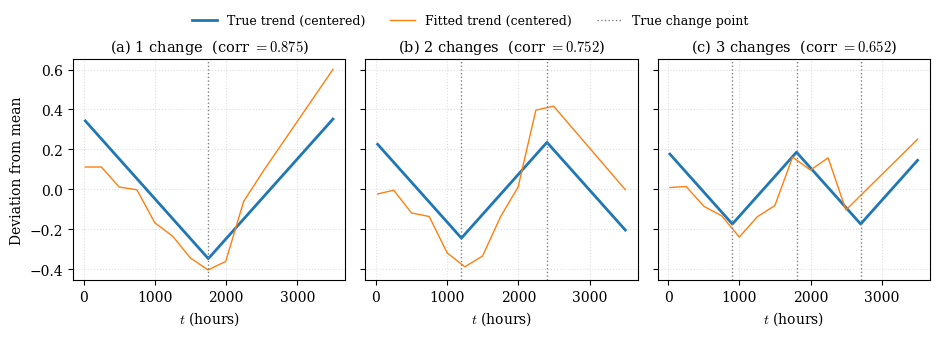

In [13]:
# =========================================================================
# Figure 4: recovery of piecewise-linear trends with one, two and three
# reversals, reference configuration at seed 42.
#
# Segment slopes alternate at +/- 4e-4, over four times the reference slope.
# Change points match the multiseed trend runs for Table 5. Everything else
# matches BASE_SIM / BASE_MODEL.
#
# Writes: figures/trend_changes_recovery.pdf (and .png preview)
# =========================================================================

SEED, S = 42, 4e-4
N = BASE_SIM['n']

CONDITIONS = {
    '1 change':  [(0, -S), (1750, S)],
    '2 changes': [(0, -S), (1200, S), (2400, -S)],
    '3 changes': [(0, -S), (900, S), (1800, -S), (2700, S)],
}

fits = {}
for name, segs in CONDITIONS.items():
    sim = {**BASE_SIM, 'seed': SEED, 'trend_segments': segs}
    d, tr = simulate_ordinal_timeseries(**sim)
    d = d.set_index('datetime')
    mdl = OrdinalNeuralProphet(d, target='aqi_category', **{**BASE_MODEL, 'seed': SEED})

    m = mdl.fitted_model
    fc = m.predict(m.make_future_dataframe(df=mdl.prophet_data,
                                           n_historic_predictions=True, periods=0))
    a = fc.merge(d.reset_index().rename(columns={'datetime': 'ds'}),
                 on='ds', how='inner').dropna(subset=['trend']).reset_index(drop=True)

    t = ((a['ds'] - pd.to_datetime(BASE_SIM.get('start_date', '2024-01-01'))) /
         pd.Timedelta('1h')).astype(int).values
    true_trend = build_trend(N, None, segs)[t]
    fit_trend  = a['trend'].astype(float).values

    fits[name] = (t, true_trend, fit_trend, segs,
                  float(np.corrcoef(fit_trend, true_trend)[0, 1]))
    print(f"{name}: corr = {fits[name][4]:.3f}")

# --- figure ---
plt.rcParams.update({
    'font.size': 10, 'font.family': 'serif',
    'axes.linewidth': 0.8, 'mathtext.fontset': 'cm',
    'axes.titlesize': 10.5, 'legend.fontsize': 9,
})
C_TRUE, C_FIT = '#1f77b4', '#ff7f0e'

fig, axes = plt.subplots(1, 3, figsize=(9.5, 3.2), sharey=True)
for k, (ax, (name, (t, tt, ft, segs, c))) in enumerate(zip(axes, fits.items())):
    ax.plot(t, tt - tt.mean(), color=C_TRUE, lw=2, label='True trend (centered)')
    ax.plot(t, ft - ft.mean(), color=C_FIT,  lw=1, label='Fitted trend (centered)')
    for j, (cp, _) in enumerate(segs[1:]):
        ax.axvline(cp, color='0.5', ls=':', lw=1,
                   label='True change point' if (k == 0 and j == 0) else None)
    ax.set_title(f'({"abc"[k]}) {name}  (corr $= {c:.3f}$)')
    ax.set_xlabel('$t$ (hours)')
    ax.grid(ls=':', alpha=0.4)

axes[0].set_ylabel('Deviation from mean')
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, frameon=False,
           bbox_to_anchor=(0.5, 1.06))

plt.tight_layout()
plt.savefig('figures/trend_changes_recovery.pdf', bbox_inches='tight')
plt.savefig('figures/trend_changes_recovery.png', dpi=300, bbox_inches='tight')
plt.show()

In [14]:
# =========================================================================
# Table 5: threshold optimization under piecewise-linear trends.
#
# Three conditions with segment slopes alternating at +/- 4e-4, one, two and
# three reversals, 40 seeds each (22-61). The reference row of Table 5 comes
# from the multiseed reference run above. Change points match Figure 4.
#
# Writes: results/multiseed_trend{1,2,3}.csv
# =========================================================================

S = 4e-4
SEGS = {
    'trend_1change':  [(0, -S), (1750, S)],
    'trend_2changes': [(0, -S), (1200, S), (2400, -S)],
    'trend_3changes': [(0, -S), (900, S), (1800, -S), (2700, S)],
}
seeds = list(range(22, 62))

metrics = (
    'quadratic_optimized_kappa', 'quadratic_baseline_kappa', 'quadratic_kappa_improvement',
    'linear_optimized_kappa',    'linear_baseline_kappa',    'linear_kappa_improvement',
    'optimized_accuracy', 'baseline_accuracy', 'optimized_mae', 'baseline_mae',
    'spearman_recovery',
)

for i, (name, segs) in enumerate(SEGS.items(), start=1):
    cfg = [make_config(name, sim=dict(trend_segments=segs))]
    res = run_experiment(cfg, seeds, save_path=f'results/multiseed_trend{i}.csv')
    print(f"\n=== {name} ===")
    pretty_summary(res, metrics=metrics)

  0%|          | 0/138 [00:00<?, ?it/s]

  0%|          | 0/138 [00:00<?, ?it/s]

[  1/40] trend_1change          seed=22 opt_kappa=0.844  (   18s)  


  0%|          | 0/138 [00:00<?, ?it/s]

  0%|          | 0/138 [00:00<?, ?it/s]

...

  0%|          | 0/138 [00:00<?, ?it/s]

[ 39/40] trend_3changes         seed=60 opt_kappa=0.908  (  721s)  


  0%|          | 0/138 [00:00<?, ?it/s]

  0%|          | 0/138 [00:00<?, ?it/s]

[ 40/40] trend_3changes         seed=61 opt_kappa=0.802  (  739s)  

=== trend_3changes ===
config                 quadratic_optimized_kappa quadratic_baseline_kappa quadratic_kappa_improvement linear_optimized_kappa  linear_baseline_kappa linear_kappa_improvement     optimized_accuracy      baseline_accuracy          optimized_mae           baseline_mae      spearman_recovery    n
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
trend_3changes                0.811 +/- 0.064        0.743 +/- 0.074        0.068 +/- 0.063        0.717 +/- 0.063        0.643 +/- 0.076        0.074 +/- 0.079        0.799 +/- 0.049        0.739 +/- 0.056        0.205 +/- 0.053        0.262 +/- 0.056        0.922 +/- 0.022   40


NOISE SWEEP

In [15]:
# =========================================================================
# Table 6 and Figure 5: robustness to noise.
#
# Sweeps the noise standard deviation across {0.15, 0.25, 0.40, 0.60, 0.80}
# with everything else at the reference configuration, 20 seeds per level
# (42-61). The reference results elsewhere pool 40 seeds, so the sigma = 0.25
# row here differs slightly from Table 4.
#
# The optimization gain stays positive at every level and roughly flat in
# sigma, in contrast to the trend conditions where it grows.
#
# Writes: results/noise_sweep.csv
# =========================================================================

configs, seeds = experiment_noise_sweep(seeds=range(42, 62))   # 20 seeds × 5 levels
results = run_experiment(configs, seeds, save_path='results/noise_sweep.csv')

pretty_summary(results, metrics=(
    'quadratic_baseline_kappa', 'quadratic_optimized_kappa', 'quadratic_kappa_improvement',
    'linear_kappa_improvement', 'spearman_recovery',
))

  0%|          | 0/138 [00:00<?, ?it/s]

  0%|          | 0/138 [00:00<?, ?it/s]

[  1/100] noise=0.15             seed=42 opt_kappa=0.879  (   18s)  


  0%|          | 0/138 [00:00<?, ?it/s]

  0%|          | 0/138 [00:00<?, ?it/s]

...

  0%|          | 0/138 [00:00<?, ?it/s]

[ 99/100] noise=0.8              seed=60 opt_kappa=0.712  ( 1817s)  


  0%|          | 0/138 [00:00<?, ?it/s]

  0%|          | 0/138 [00:00<?, ?it/s]

[100/100] noise=0.8              seed=61 opt_kappa=0.610  ( 1835s)  
config                 quadratic_baseline_kappa quadratic_optimized_kappa quadratic_kappa_improvement linear_kappa_improvement      spearman_recovery    n
----------------------------------------------------------------------------------------------------------------------------------------------------------
noise=0.15                    0.811 +/- 0.051        0.853 +/- 0.063        0.042 +/- 0.043        0.052 +/- 0.059        0.947 +/- 0.017   20
noise=0.25                    0.791 +/- 0.055        0.843 +/- 0.076        0.052 +/- 0.056        0.066 +/- 0.086        0.931 +/- 0.022   20
noise=0.4                     0.755 +/- 0.059        0.793 +/- 0.070        0.039 +/- 0.053        0.051 +/- 0.073        0.895 +/- 0.036   20
noise=0.6                     0.666 +/- 0.077        0.714 +/- 0.093        0.049 +/- 0.056        0.057 +/- 0.071        0.823 +/- 0.064   20
noise=0.8                     0.575 +/- 0.108    

In [16]:
# =========================================================================
# Section 4.1.5: a single extra noise level at sigma = 1.0, beyond the range
# in Table 6, to check that the optimization gain does not reverse at high
# noise. Reported in the text as a gain of +0.044 with Spearman 0.666.
# Same 20 seeds as the sweep.
#
# Writes: results/noise_100.csv
# =========================================================================

configs = [make_config('noise=1.0', sim=dict(noise_std=1.0))]
seeds = list(range(42, 62))   # same seeds as the rest of the sweep

results = run_experiment(configs, seeds, save_path='results/noise_100.csv')

pretty_summary(results, metrics=(
    'quadratic_baseline_kappa', 'quadratic_optimized_kappa', 'quadratic_kappa_improvement',
    'linear_kappa_improvement', 'spearman_recovery',
))

  0%|          | 0/138 [00:00<?, ?it/s]

  0%|          | 0/138 [00:00<?, ?it/s]

[  1/20] noise=1.0              seed=42 opt_kappa=0.641  (   18s)  


  0%|          | 0/138 [00:00<?, ?it/s]

  0%|          | 0/138 [00:00<?, ?it/s]

...

  0%|          | 0/138 [00:00<?, ?it/s]

[ 19/20] noise=1.0              seed=60 opt_kappa=0.625  (  340s)  


  0%|          | 0/138 [00:00<?, ?it/s]

  0%|          | 0/138 [00:00<?, ?it/s]

[ 20/20] noise=1.0              seed=61 opt_kappa=0.560  (  358s)  
config                 quadratic_baseline_kappa quadratic_optimized_kappa quadratic_kappa_improvement linear_kappa_improvement      spearman_recovery    n
----------------------------------------------------------------------------------------------------------------------------------------------------------
noise=1.0                     0.512 +/- 0.096        0.556 +/- 0.105        0.044 +/- 0.048        0.050 +/- 0.044        0.666 +/- 0.112   20


       base_m  base_s  opt_m  opt_s
sigma                              
0.15    0.811   0.051  0.853  0.063
0.25    0.791   0.055  0.843  0.076
0.40    0.755   0.059  0.793  0.070
0.60    0.666   0.077  0.714  0.093
0.80    0.575   0.108  0.629  0.105


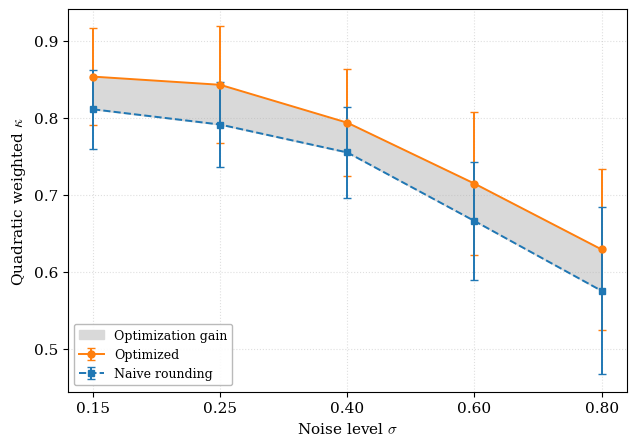

In [17]:
# =========================================================================
# Figure 5: quadratic weighted kappa under naive rounding and threshold
# optimization as a function of the noise level, with the shaded region
# marking the optimization gain.
#
# Reads results/noise_sweep.csv, so the sweep cell above does not need to be
# re-run. Error bars are one standard deviation across the 20 seeds at each
# level.
#
# Writes: figures/noise_sweep.pdf (and .png preview)
# =========================================================================

res = pd.read_csv('results/noise_sweep.csv')
res = res[res['status'] == 'ok']

# config strings are 'noise=0.15' etc.; pull the level out and sort numerically
res['sigma'] = res['config'].str.split('=').str[-1].astype(float)

g = res.groupby('sigma').agg(
    base_m=('quadratic_baseline_kappa', 'mean'),
    base_s=('quadratic_baseline_kappa', 'std'),
    opt_m =('quadratic_optimized_kappa', 'mean'),
    opt_s =('quadratic_optimized_kappa', 'std'),
).sort_index()
print(g.round(3))

x = np.arange(len(g))          # even spacing, so 0.15..0.80 are equidistant

plt.rcParams.update({
    'font.size': 11, 'font.family': 'serif',
    'axes.linewidth': 0.8, 'mathtext.fontset': 'cm',
})

fig, ax = plt.subplots(figsize=(6.5, 4.6))

ax.fill_between(x, g['base_m'], g['opt_m'], color='0.85', zorder=1,
                label='Optimization gain')
ax.errorbar(x, g['opt_m'], yerr=g['opt_s'], color='#ff7f0e', marker='o',
            ms=5, lw=1.4, capsize=3, zorder=3, label='Optimized')
ax.errorbar(x, g['base_m'], yerr=g['base_s'], color='#1f77b4', marker='s',
            ms=5, lw=1.4, ls='--', capsize=3, zorder=3, label='Naive rounding')

ax.set_xticks(x)
ax.set_xticklabels([f'{s:.2f}' for s in g.index])
ax.set_xlabel(r'Noise level $\sigma$')
ax.set_ylabel(r'Quadratic weighted $\kappa$')
ax.legend(loc='lower left', frameon=True, framealpha=0.9, edgecolor='0.7')
ax.grid(ls=':', alpha=0.4, zorder=0)

plt.tight_layout()
plt.savefig('figures/noise_sweep.pdf', bbox_inches='tight')
plt.savefig('figures/noise_sweep.png', dpi=300, bbox_inches='tight')
plt.show()

In [18]:
# =========================================================================
# Section 4.1.3: noise-to-signal ratios used to calibrate the simulator.
#
# Fits Beijing explicitly (rather than relying on whichever `model` was last
# built) and takes the ratio of residual SD to the SD of the summed
# structural components on the integer-label scale. The same ratio is then
# measured on a realised simulated series, so the two are computed the same
# way.
#
# Quadrature over component SDs is not used: it assumes the components are
# independent, but the simulated covariates are correlated by construction
# (X1 and X2 at rho=0.7, X3 anticorrelated with X1), so it overstates the
# structural SD and understates the ratio.
# =========================================================================

# --- Beijing ---
bj = pd.read_csv('data/BeijingAQI_data.csv', parse_dates=['datetime']).set_index('datetime')
bj_model = OrdinalNeuralProphet(
    bj, 'aqi_category',
    **{**BASE_MODEL, 'seed': 42,
       'covariates':        ['TEMP', 'DEWP', 'PRES', 'Iws'],
       'future_covariates': ['TEMP', 'DEWP', 'PRES', 'Iws']}
)

m = bj_model.fitted_model
future = m.make_future_dataframe(df=bj_model.prophet_data,
                                 n_historic_predictions=True, periods=0)
fc = m.predict(future)

comp_cols = ['trend', 'season_daily', 'season_weekly', 'future_regressors_additive']
present = [c for c in comp_cols if c in fc.columns]
fc = fc.dropna(subset=present + ['yhat1']).reset_index(drop=True)

resid    = (fc['y'].astype(float) - fc['yhat1'].astype(float)).values
resid_sd = resid.std()

daily_amp  = fc['season_daily'].astype(float).std()  if 'season_daily'  in fc else np.nan
weekly_amp = fc['season_weekly'].astype(float).std() if 'season_weekly' in fc else np.nan
cov_amp    = fc['future_regressors_additive'].astype(float).std() if 'future_regressors_additive' in fc else np.nan
structural_sd = fc[present].astype(float).sum(axis=1).std()

print("Beijing AQI")
print(f"  residual SD (label scale):   {resid_sd:.3f}")
print(f"  daily seasonality SD:        {daily_amp:.3f}")
print(f"  weekly seasonality SD:       {weekly_amp:.3f}")
print(f"  covariate contribution SD:   {cov_amp:.3f}")
print(f"  structural SD (summed):      {structural_sd:.3f}")
print(f"  noise-to-signal ratio:       {resid_sd/structural_sd:.3f}")

# --- simulator, measured on a realised series ---
d_sim, tr_sim = simulate_ordinal_timeseries(**{**BASE_SIM, 'seed': 42})
t_sim = np.arange(BASE_SIM['n'])
Xs = ((d_sim[['X1', 'X2', 'X3', 'X4']].to_numpy(float)
       - np.array(tr_sim['covariate_means_pre_std']))
      / np.array(tr_sim['covariate_stds_pre_std']))

structural_sim = (
    tr_sim['trend_slope'] * t_sim
    + tr_sim['daily_amplitude']  * np.sin(2*np.pi*t_sim/24  + tr_sim['daily_phase'])
    + tr_sim['weekly_amplitude'] * np.sin(2*np.pi*t_sim/168 + tr_sim['weekly_phase'])
    + Xs @ np.array(tr_sim['betas'])
)
sd_struct = structural_sim.std()

print(f"\nSimulator structural SD (measured): {sd_struct:.3f}")
for sigma in (0.15, 0.25, 0.40, 0.60, 0.80):
    print(f"  sigma={sigma:.2f}: noise-to-signal = {sigma/sd_struct:.3f}")

Data split:
  Training:   2976 samples (indices 0 to 2975)
  Validation: 500 samples (indices 2976 to 3475)
  Test:       72 samples (indices 3476 to 3547)
  Val mode:   refit (model fit on train+validation; thresholds tuned on its own validation predictions)


  0%|          | 0/138 [00:00<?, ?it/s]

  0%|          | 0/138 [00:00<?, ?it/s]

Beijing AQI
  residual SD (label scale):   0.441
  daily seasonality SD:        0.090
  weekly seasonality SD:       0.062
  covariate contribution SD:   1.304
  structural SD (summed):      0.961
  noise-to-signal ratio:       0.459

Simulator structural SD (measured): 0.826
  sigma=0.15: noise-to-signal = 0.182
  sigma=0.25: noise-to-signal = 0.303
  sigma=0.40: noise-to-signal = 0.484
  sigma=0.60: noise-to-signal = 0.726
  sigma=0.80: noise-to-signal = 0.969
